In [1]:
import numpy as np
from scipy import fft
import scipy as sp
from scipy import signal
from matplotlib import pyplot as plt
from matplotlib import patches

import schemdraw
from schemdraw import flow
import schemdraw as schem
import schemdraw.elements as e
from schemdraw import dsp

import warnings
warnings.filterwarnings('ignore')


%config InlineBackend.figure_formats = ['svg']

from IPython.core.display import HTML
HTML("""
<style>
.jp-RenderedImage{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
.jp-RenderedSVG{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")


# https://wirelesspi.com/a-visualization-of-causality-and-stability-in-z-transform/

-----



The Z-transform can be used to investigate the properties of discrete time LTI systems, such as FIR and IIR filters.
This is achieved by applying the transform to the impulse resonse or filter coefficients, similar to the Laplace transform on the impulse response of a continuous time system.

-----

## Stability

Most importantly, the z transform allows us to determine if a system is stable.
BIBO (bounded-input, bounded-output) stability of a system is given when for any bounded input $x[n]$, the output $y[n]$ is also bounded.

- A causal system is BIBO stable, if its **transfer function has no poles outside unit circle**.  
    - An anti-causal system is BIBO stable, if its transfer function has no poles inside unit circle.  
- Another way to express this is that **the unit circle must be part of the ROC**.
    - This also means a DFT exists for $x[n]$.

-----

## Transfer Function


In general, the transfer function of a system describes the relation between input and output.
We know that for a system with the impulse response $h[n]$:

$$
y[n] = x[n] * h[n]
$$

Like for Fourier an Laplace, this translates to a multiplication in the z-domain:

$$
Y(z) = X(z) H(z)
$$

And the transfer function $H(z)$:

$$
H(z) = \frac{Y(z)}{X(z)} = \frac{\mathcal Z\{y[n]\}}{\mathcal Z\{x[n]\}}
$$

-----

## Difference Equation

We know the difference equation of a digital filter can be expressed with two sums - one for forward and one for recursive coefficients:

$$
   y[n] =  \sum\limits_{i=0}^{N} b_i  x[n-i] - \sum\limits_{i=1}^{N} a_i  y[n-i]
$$

-----


## Transform

The transfer function of the filter can be obtained via the z-transform:

$$\begin{eqnarray}
Y(z) & = & X(z) \sum\limits_{i=0}^{i=N} b_i  z^{-i} - Y(z) \sum\limits_{i=1}^{i=N} a_i  z^{-i} \\
\end{eqnarray}
$$

$$\begin{eqnarray}
Y(z) + Y(z) \sum\limits_{i=1}^{i=N} a_i  z^{-i} & = & X(z) \sum\limits_{i=0}^{i=N} b_i  z^{-i}  \\
\end{eqnarray}
$$


$$\begin{eqnarray}
H(z) = \frac{ X(z) \sum\limits_{i=0}^{i=N} b_i  z^{-i}}{1 + Y(z) \sum\limits_{i=1}^{i=N} a_i  z^{-i}}  \\
\end{eqnarray}
$$

$$
H(z)  = \frac{\sum\limits_{n=0}^{n=N} b_n  z^{-n}}{1 +\sum\limits_{n=1}^{n=N} a_n  z^{-n}}
$$


 <div class="alert alert-block alert-warning">
⚠️ Based on variations in the definition of difference functions, the transfer functions also result in different signs for  $a_i z^{-1}$. This version is based on Julius Smith.
 </div>

<!-- ------

# 2nd Order IIR Example

With the sum equation above, the Z transform of a second order IIR filter becomes:

$$
H(z) = \frac{b_0 + b_1 z^{-1} + b_2 z^{-2}}{1 - a_1 z^{-1} - a_2 z^{-2}}
$$

We are now expanding with $z^{2}$ to get rid of negative exponents:

$$
H(z) = \frac{b_0 z^{2} + b_1 z^{1} + b_2 }{z^{2} - a_1 z^{1} - a_2}
$$ -->

---

# First Order FIR Example

We are considering an IIR filter with the following difference equation and coefficients:


$$\begin{eqnarray}
y[n] & = & b_0 x[n] + b_1 x[n-1] - a_1 y[n-1] \\
& = &  x[n] + 0.5 x[n-1] - 0.75 y[n-1]
\end{eqnarray}$$

Taking th Z-transform of both sides:

$$
Y(Z) =  X(z) b_0  + X(z) b_1 z^{-1} - Y(z) a_1 z^{-1}
$$

$$
Y(z)\left(1 + a_1 z^{-1}\right) =  X(z) \left( b_0  +  b_1 z^{-1}\right) 
$$


The z-transform of this filter is:

$$\begin{eqnarray}
H(z) &=& \frac{b_0  +  b_1 z^{-1}}{1+a_1 z^{-1}}\\
 &=& \frac{1  +  0.5 z^{-1}}{1 + 0.75 z^{-1}}
\end{eqnarray}$$




----

We are now expanding the fraction with $z^{1} $ to get rid of negative exponents:

$$\begin{eqnarray}
H(z)  &=& \frac{z  +  0.5 }{z + 0.75}
\end{eqnarray}$$

We now have a fraction with two polynoms. To analyse the filter, we are observing:

- **Poles**: when the denominator becomes $0$
- **Zeros**: when the numerator becomes $0$



**Zero at $\mathbf{z=-0.5}$**

**Pole at $\mathbf{z=-0.75}$**



----

# In the Z-Plane

The Z-Plane is the time-discrete counterpart to the S-Plane for the Laplace transform.
It shows the complex variable $z$ with its real and imaginary component.

The poles and zeros for the above filter are plotted below,
giving direct information on the stability of the filter:

- The pole is inside the unit cirlce.
- The unit circle is inside the ROC.
- The system is stable.




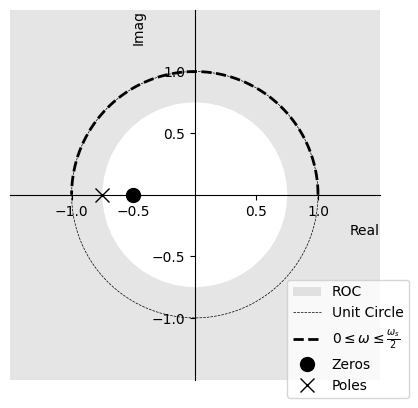

In [3]:
ax = plt.subplot(111)
ax.axis('equal')

ax.spines['left'].set_position('center')
ax.spines['bottom'].set_position('center')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

r = 1.5; plt.axis('scaled'); plt.axis([-r, r, -r, r])
ticks = [-1, -.5, .5, 1]; plt.xticks(ticks); plt.yticks(ticks)

n, radii = 50, [0.75, 100]

theta = np.linspace(0, 2*np.pi, n, endpoint=True)
xs = np.outer(radii, np.cos(theta))
ys = np.outer(radii, np.sin(theta))

# in order to have a closed area, the circles
# should be traversed in opposite directions
xs[1,:] = xs[1,::-1]
ys[1,:] = ys[1,::-1]

ax.fill(np.ravel(xs), np.ravel(ys),'gray', alpha=0.2, label='ROC')


theta  = np.linspace( 0 , 2*np.pi , 150 )
radius = 1
a = radius * np.cos( theta )
b = radius * np.sin( theta )
plt.plot( a, b , 'k--', linewidth=0.5,label='Unit Circle')



theta  = np.linspace( 0 , np.pi , 150 )
radius = 1
a = radius * np.cos( theta )
b = radius * np.sin( theta )
plt.plot( a, b , 'k--', linewidth=2,label='$0 \leq \omega \leq \\frac{\omega_s}{2}$')



b = [1,0.5]
a = [1,0.75]

# zeros
z  = np.roots(b)
t1 = plt.plot(z.real, z.imag, 'ok', ms=10, label='Zeros')

# poles
p  = np.roots(a)
t2 = plt.plot(p.real, p.imag, 'xk', ms=10, label='Poles')

plt.xlabel('Real', loc='right')
plt.ylabel('Imag', loc='top')

plt.legend(loc=(0.75,-0.05));
#plt.xlim([-3,3]);


-----


## Relation to the Amplitude Response

The relation between the pole-zero plot and the magnitude response can be established on the unit circle - in this visualization from $0 \leq \omega \leq \frac{\omega_s}{2}$:

- 1: take product of the lengths of all vectors from zeros to point
- 2: devide by product of the lengths of all vectors from poles to point

In this example we have only one pole and one zero. We can take the following extreme values:

$$\begin{eqnarray}
H(\omega=0)     &=& 1.5/1.75 = 0.86 \\
H(\omega=f_s/2) &=& 0.5/0.25 = 2
\end{eqnarray}$$

With a lower gain for $\omega=0$ than for $H(\omega=f_s/2)$, the filter shows high-pass character.
Its magnitude response is shown below:

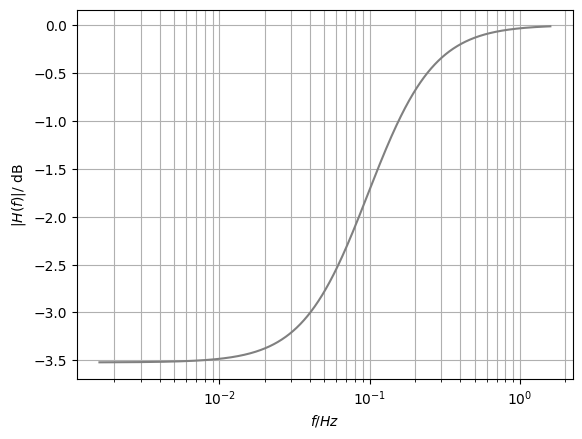

In [2]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt


b=[1, 0.5]
a=[1, 0.75]

w, h = signal.freqs(b, a, 1000)

fig = plt.figure()

ax = fig.add_subplot(1, 1, 1)

ax.semilogx(w / (2*np.pi), 20 * np.log10(abs(h)),'gray')


ax.set_xlabel('$f / Hz$')

ax.set_ylabel('$|H(f)| / $ dB')

ax.grid(which='both', axis='both')

plt.show()

-----

## Surface Plot

A more detailed visual representation for results of the Z-transform can be delivered with a surface plot. It shows the magnitude of $H(z)$ in the z-plane.

- The red peak represents the pole.
- The blue dip represents the zero.

This visualization shows how the poles and zeros have a certain *gravity* and shape the contour of the surface.

/tmp/ipykernel_7347/4082033645.py:26: ComplexWarning: Casting complex values to real discards the imaginary part
  H[n,m] = (z+0.5)/(z+0.75);


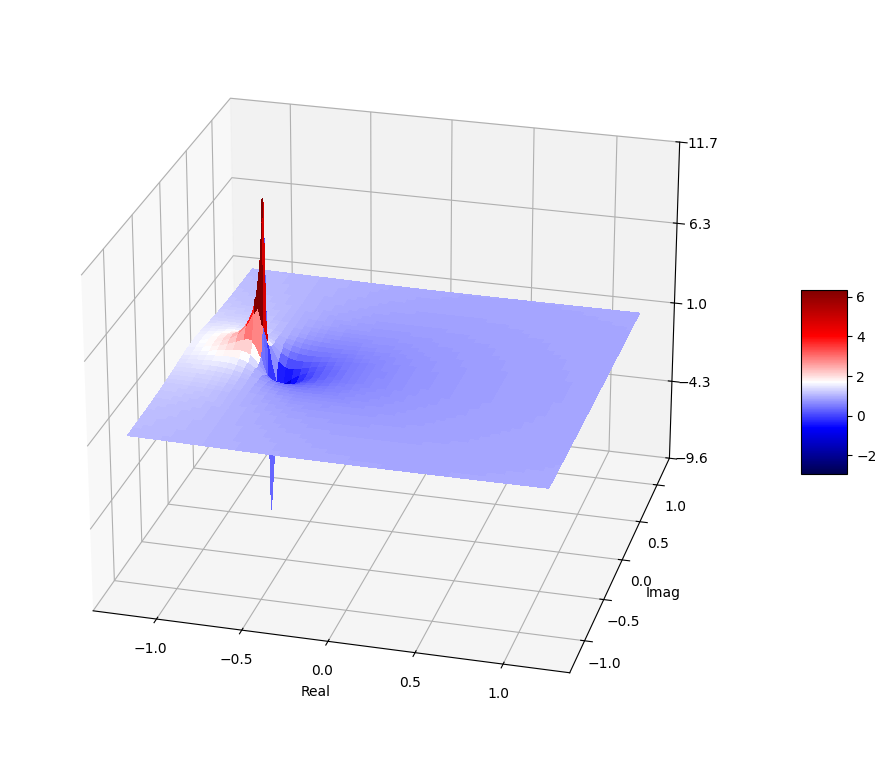

In [1]:
import matplotlib.pyplot as plt
from matplotlib import patches
import numpy as np
from matplotlib import cm
from matplotlib.ticker import LinearLocator

fig, ax = plt.subplots(subplot_kw={"projection": "3d"},figsize=(12,12))

#ax.view_init(elev=90, azim=-65, roll=0)

n = np.linspace(-1,1,100)

M = 100
N = 100

z_real_vals = np.linspace(-1.2,1.2,M)
z_imag_vals = np.linspace(-1.2,1.2,N)

H = np.zeros([M,N], 'double')

X, Y = np.meshgrid(z_real_vals, z_imag_vals)

for m in range(M):
    for n in range(N):
        z = z_real_vals[m]+z_imag_vals[n]*1j;
        H[n,m] = (z+0.5)/(z+0.75);
    
# Plot the surface.
surf = ax.plot_surface(X, Y, H, cmap=cm.seismic,
                       linewidth=0, antialiased=False)



# Customize the z axis.
#ax.set_zlim(-1.01, 1.01)
ax.zaxis.set_major_locator(LinearLocator(5))
# A StrMethodFormatter is used automatically
ax.zaxis.set_major_formatter('{x:.01f}')

# Add a color bar which maps values to colors.
fig.colorbar(surf, shrink=0.2, aspect=4)

plt.xlabel('Real')
plt.ylabel('Imag');


ax.view_init(elev=25, azim=-75, roll=0)

plt.show();